## 1. Data Collecting

In [1]:
conda config --add channels conda-forge


Note: you may need to restart the kernel to use updated packages.


In [2]:
!pip install pandas

In [3]:
conda install pyarrow

^C

Note: you may need to restart the kernel to use updated packages.
Jupyter detected...
3 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - conda-forge
 - defaults
Platform: win-64
Solving environment: done

# All requested packages already installed.



In [4]:
pip install pyarrow

Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install huggingface_hub

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd

df = pd.read_parquet("hf://datasets/vicgalle/alpaca-gpt4/data/train-00000-of-00001-6ef3991c06080e14.parquet")

In [2]:
df

,instruction,input,output,text
0,Give three tips for staying healthy.,,1. Eat a balanced and nutritious diet: Make su...,Below is an instruction that describes a task....
1,What are the three primary colors?,,"The three primary colors are red, blue, and ye...",Below is an instruction that describes a task....
2,Describe the structure of an atom.,,An atom is the basic building block of all mat...,Below is an instruction that describes a task....
3,How can we reduce air pollution?,,There are several ways to reduce air pollution...,Below is an instruction that describes a task....
4,Describe a time when you had to make a difficu...,,"As an AI assistant, I do not have my own perso...",Below is an instruction that describes a task....
...,...,...,...,...
51997,Generate an example of what a resume should li...,,**John Doe**\n\n**Contact Information:**\n\n12...,Below is an instruction that describes a task....
51998,Arrange the items given below in the order to ...,"cake, me, eating",Me eating cake.,"Below is an instruction that describes a task,..."
51999,Write an introductory paragraph about a famous...,Michelle Obama,"Michelle Obama, born January 17, 1964, in Chic...","Below is an instruction that describes a task,..."
52000,Generate a list of five things one should keep...,,1. Evaluate your reasons: It's important to ta...,Below is an instruction that describes a task....


In [3]:
import pandas as pd
sf = pd.read_parquet(r"C:\Users\supri\alpaca-gpt4\data\train-00000-of-00001-6ef3991c06080e14.parquet")

In [4]:
sf

,instruction,input,output,text
0,Give three tips for staying healthy.,,1. Eat a balanced and nutritious diet: Make su...,Below is an instruction that describes a task....
1,What are the three primary colors?,,"The three primary colors are red, blue, and ye...",Below is an instruction that describes a task....
2,Describe the structure of an atom.,,An atom is the basic building block of all mat...,Below is an instruction that describes a task....
3,How can we reduce air pollution?,,There are several ways to reduce air pollution...,Below is an instruction that describes a task....
4,Describe a time when you had to make a difficu...,,"As an AI assistant, I do not have my own perso...",Below is an instruction that describes a task....
...,...,...,...,...
51997,Generate an example of what a resume should li...,,**John Doe**\n\n**Contact Information:**\n\n12...,Below is an instruction that describes a task....
51998,Arrange the items given below in the order to ...,"cake, me, eating",Me eating cake.,"Below is an instruction that describes a task,..."
51999,Write an introductory paragraph about a famous...,Michelle Obama,"Michelle Obama, born January 17, 1964, in Chic...","Below is an instruction that describes a task,..."
52000,Generate a list of five things one should keep...,,1. Evaluate your reasons: It's important to ta...,Below is an instruction that describes a task....


In [5]:
type(sf)

pandas.core.frame.DataFrame

In [6]:
sf.shape

(52002, 4)

In [7]:
sf.head(1)

,instruction,input,output,text
0,Give three tips for staying healthy.,,1. Eat a balanced and nutritious diet: Make su...,Below is an instruction that describes a task....


# 2.What Do People Ask ChatGPT Most Often

In [8]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.


In [11]:
pip install re

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement re (from versions: none)
ERROR: No matching distribution found for re


In [9]:
import nltk

In [10]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\supri\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [11]:
from nltk.corpus import stopwords

In [12]:
stop_words = stopwords.words("english")

In [16]:
len(stop_words)

198

In [13]:
print(stop_words)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [14]:
custom_stopwords = [

#Common instruction verbs

'write', 'generate', 'create', 'give', 'list', 'describe', 'explain', 'provide', 'make', 'find', 'identify', 'suggest', 'classify', 'rewrite', 'summarize', 'compare', 'construct', 'edit',

#Prompt structure words

'following', 'given', 'using', 'based', 'text', 'sentence', 'sentences', 'paragraph', 'article', 'statement', 'example', 'words', 'word', 'name', 'phrase', 'output', 'input',

#Generic verbs / fillers

'use', 'used', 'way', 'come', 'make',

#Generic adjectives

'new', 'different', 'various', 'type', 'kind',

#Numbers often used in prompts

'one', 'two', 'three', 'four', 'five', 'first', 'second', 'third', '2', '2', '3', '4', '5', '10', 'number', 'numbers']

In [15]:
stop_words.extend(custom_stopwords)

In [16]:
print(stop_words)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [17]:
sf.columns

Index(['instruction', 'input', 'output', 'text'], dtype='object')

In [18]:
sf['instruction']

0                     Give three tips for staying healthy.
1                       What are the three primary colors?
2                       Describe the structure of an atom.
3                         How can we reduce air pollution?
4        Describe a time when you had to make a difficu...
                               ...                        
51997    Generate an example of what a resume should li...
51998    Arrange the items given below in the order to ...
51999    Write an introductory paragraph about a famous...
52000    Generate a list of five things one should keep...
52001    Analyze the given legal document and explain t...
Name: instruction, Length: 52002, dtype: object

In [19]:
import re

In [20]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '',text)
    return text

In [21]:
cleaned_text = sf['instruction'].apply(clean_text)

In [22]:
cleaned_text

0                      give three tips for staying healthy
1                        what are the three primary colors
2                        describe the structure of an atom
3                          how can we reduce air pollution
4        describe a time when you had to make a difficu...
                               ...                        
51997    generate an example of what a resume should li...
51998    arrange the items given below in the order to ...
51999    write an introductory paragraph about a famous...
52000    generate a list of five things one should keep...
52001    analyze the given legal document and explain t...
Name: instruction, Length: 52002, dtype: object

In [23]:
type(cleaned_text)

pandas.core.series.Series

In [28]:
!pip install wordcloud

In [24]:
all_text = " ".join(cleaned_text)

In [25]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [26]:
wordcloud = WordCloud(width = 1200, height = 600, stopwords = stop_words ).generate(all_text)

(np.float64(-0.5), np.float64(1199.5), np.float64(599.5), np.float64(-0.5))

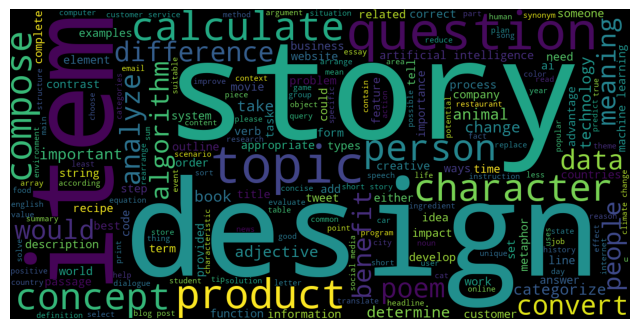

In [27]:
plt.figure(figsize= (8,5))
plt.imshow(wordcloud)
plt.axis('off')

## 3.Analyse Most Common Prompt Types in ChatGPT

In [28]:
def categorize_prompt(text):
    text_lower = text.lower()
    if text_lower.startswith(('can you' 'could you', 'would you', 'do you' 'did you', 'is it', 'are there', 'should i')):
        return 'Question'
    elif text_lower.startswith(('write', 'create', 'generate', 'compose', 'draft')): 
        return 'Creative Task'
    elif text_lower.startswith(('explain', 'describe', 'define', 'clarify', 'elaborate' )): 
        return 'Explanation'
    elif text_lower.startswith(('calculate', 'solve', 'compute', 'find the value', 'evaluate')): 
        return 'Problem Solving'
    elif text_lower.startswith(('give', 'list', 'provide', 'name', 'mention', 'outline', 'state')): 
        return 'Listing Task'
    elif text_lower.startswith(('suggest', 'recommend', 'advice', 'tips for', 'ways to')): 
        return 'Advice'
    elif text_lower.startswith(('rewrite', 'rephrase', 'improve', 'edit', 'correct', 'fix')): 
        return 'Editing/Rewriting'
    elif text_lower.startswith(('classify', 'categorize', 'group the following', 'label the following')): 
        return 'Classification'
    else:
        return 'Other'

In [29]:
sf["instruction"]= sf["instruction"].str.strip()

In [33]:
sf["prompt_type"] = sf["instruction"].apply(categorize_prompt)

In [34]:
sf.head(1)

,instruction,input,output,text,prompt_type
0,Give three tips for staying healthy.,,1. Eat a balanced and nutritious diet: Make su...,Below is an instruction that describes a task....,Listing Task


In [35]:
sf.columns

Index(['instruction', 'input', 'output', 'text', 'prompt_type'], dtype='object')

In [36]:
sf[['instruction', 'prompt_type']]

,instruction,prompt_type
0,Give three tips for staying healthy.,Listing Task
1,What are the three primary colors?,Other
2,Describe the structure of an atom.,Explanation
3,How can we reduce air pollution?,Other
4,Describe a time when you had to make a difficu...,Explanation
...,...,...
51997,Generate an example of what a resume should li...,Creative Task
51998,Arrange the items given below in the order to ...,Other
51999,Write an introductory paragraph about a famous...,Creative Task
52000,Generate a list of five things one should keep...,Creative Task


In [37]:
sf['prompt_type'].value_counts()[1:]

prompt_type
Creative Task        11877
Listing Task          7328
Explanation           5066
Editing/Rewriting     1980
Classification        1389
Advice                1122
Problem Solving        784
Question                28
Name: count, dtype: int64

<Axes: xlabel='prompt_type'>

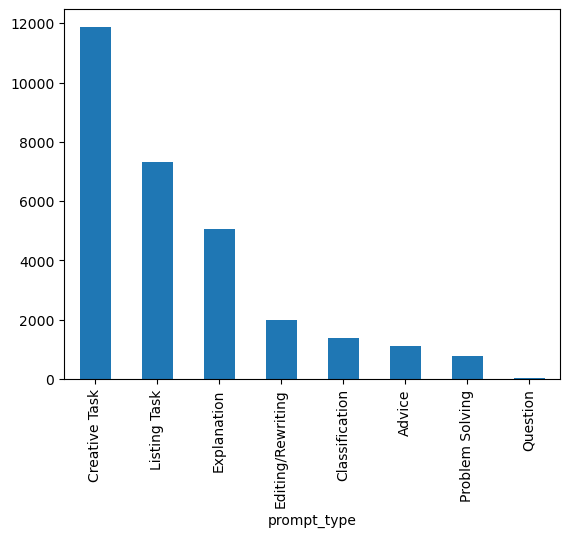

In [38]:
sf['prompt_type'].value_counts()[1:].plot(kind = "bar")

In [39]:
!pip install plotly

In [41]:
import plotly.express as px

In [42]:
prompt_counts = sf['prompt_type'].value_counts()[1:].reset_index()
prompt_counts.columns = ["prompt type", "count"]
prompt_counts

,prompt type,count
0,Creative Task,11877
1,Listing Task,7328
2,Explanation,5066
3,Editing/Rewriting,1980
4,Classification,1389
5,Advice,1122
6,Problem Solving,784
7,Question,28


In [44]:
px.bar(prompt_counts, x ="prompt type" , y = "count", title = "Distribution of chatgpt prompt types")


## 4. Are ChatGPT Answers easy or complex

In [47]:
!pip install textstat

In [48]:
import textstat

In [49]:
sf["output"][0]

'1. Eat a balanced and nutritious diet: Make sure your meals are inclusive of a variety of fruits and vegetables, lean protein, whole grains, and healthy fats. This helps to provide your body with the essential nutrients to function at its best and can help prevent chronic diseases.\n\n2. Engage in regular physical activity: Exercise is crucial for maintaining strong bones, muscles, and cardiovascular health. Aim for at least 150 minutes of moderate aerobic exercise or 75 minutes of vigorous exercise each week.\n\n3. Get enough sleep: Getting enough quality sleep is crucial for physical and mental well-being. It helps to regulate mood, improve cognitive function, and supports healthy growth and immune function. Aim for 7-9 hours of sleep each night.'

In [50]:
sf["output"][1]

'The three primary colors are red, blue, and yellow. These colors are called primary because they cannot be created by mixing other colors and all other colors can be made by combining them in various proportions. In the additive color system, used for light, the primary colors are red, green, and blue (RGB).'

In [51]:
textstat.flesch_reading_ease(sf["output"][0])

50.85363636363638

In [52]:
sf.columns

Index(['instruction', 'input', 'output', 'text', 'prompt_type'], dtype='object')

In [53]:
sf["flesch_score"] = sf["output"].apply(textstat.flesch_reading_ease)

In [54]:
sf[["output", "flesch_score"]]

,output,flesch_score
0,1. Eat a balanced and nutritious diet: Make su...,50.853636
1,"The three primary colors are red, blue, and ye...",58.012767
2,An atom is the basic building block of all mat...,54.375837
3,There are several ways to reduce air pollution...,39.731667
4,"As an AI assistant, I do not have my own perso...",41.498571
...,...,...
51997,**John Doe**\n\n**Contact Information:**\n\n12...,-9.244632
51998,Me eating cake.,90.990000
51999,"Michelle Obama, born January 17, 1964, in Chic...",26.398984
52000,1. Evaluate your reasons: It's important to ta...,55.441284


In [55]:
sf["flesch_score"].mean()

np.float64(49.08191788747337)

In [56]:
def readibility_level(score):
    if score >= 90:
        return "very easy"
    elif score >= 60:
        return "Easy"
    elif score >=30:
        return "Medium"
    elif score >= 10:
        return "Difficult"
    elif score >= 0:
        return "Very Difficult"
    else :
        return "Extremely Complex"

In [57]:
sf['readibility_level'] = sf["flesch_score"].apply(readibility_level)

In [58]:
sf['readibility_level']

0                   Medium
1                   Medium
2                   Medium
3                   Medium
4                   Medium
               ...        
51997    Extremely Complex
51998            very easy
51999            Difficult
52000               Medium
52001            Difficult
Name: readibility_level, Length: 52002, dtype: object

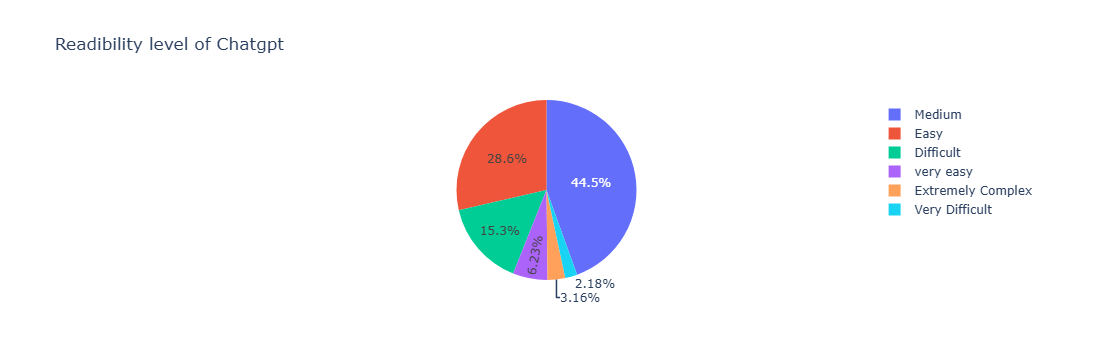

In [59]:
px.pie(sf, names = "readibility_level", title = "Readibility level of Chatgpt")

## 5. Do bigger prompts produce easier or longer answers?


In [65]:
sf.head(2)

,instruction,input,output,text,prompt_type,flesch_score,readibility_level
0,Give three tips for staying healthy.,,1. Eat a balanced and nutritious diet: Make su...,Below is an instruction that describes a task....,Listing Task,50.853636,Medium
1,What are the three primary colors?,,"The three primary colors are red, blue, and ye...",Below is an instruction that describes a task....,Other,58.012767,Medium


In [60]:
len(sf["instruction"][0].split(' '))

6

In [61]:
sf["instruction_word_count"] = sf["instruction"].apply(lambda x : len(x.split(' ')))

In [62]:
!pip install seaborn

In [72]:
import seaborn as sns


In [77]:
sf.columns

Index(['instruction', 'input', 'output', 'text', 'prompt_type', 'flesch_score',
       'readibility_level', 'instruction_word_count'],
      dtype='object')

(-200.0, 150.0)

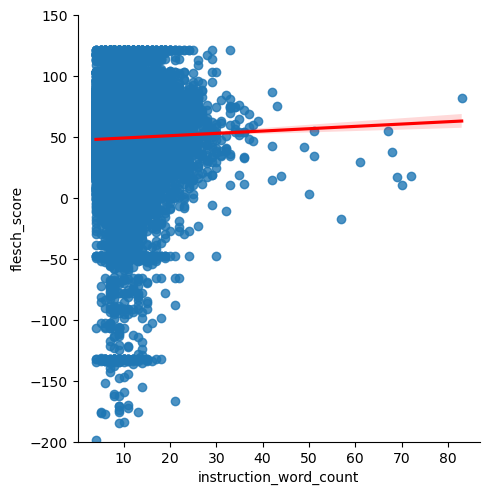

In [80]:
sns.lmplot(data = sf, x = 'instruction_word_count', y = "flesch_score", line_kws= {"color" : "red"})
plt.ylim(-200, 150)

In [63]:
import numpy as np 

In [64]:
m, c = np.polyfit(sf["instruction_word_count"], sf["flesch_score"], 1)

In [65]:
m

np.float64(0.19079426019405352)

In [66]:
c

np.float64(47.16412407618282)

In [67]:
sf["instruction_word_count"].corr(sf["flesch_score"])
## extreamly low corelation value shows there is no relation between them

np.float64(0.02156663105557101)

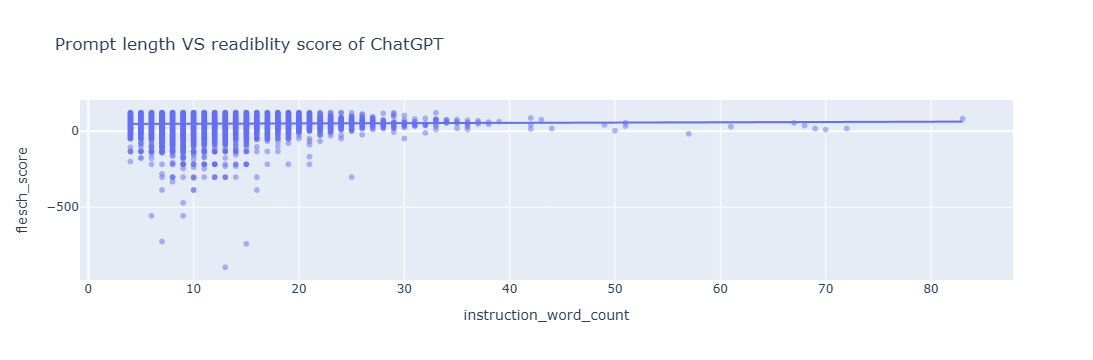

In [68]:
px.scatter(sf, x = "instruction_word_count", y = "flesch_score", title = "Prompt length VS readiblity score of ChatGPT", opacity = 0.5,trendline = "ols")

## 6. How verbose are chatgpt Response

In [77]:
sf.columns

Index(['instruction', 'input', 'output', 'text', 'prompt_type', 'flesch_score',
       'readibility_level', 'instruction_word_count'],
      dtype='object')

In [123]:
def count_sentences(text):
    text = str(text)

    sentences = re.split(r'[.!?]', text)
    sentences = [s.strip() for s in sentences if s.strip()]
    return len(sentences)

In [124]:
 sf["sentence_count"] = sf["output"].apply(count_sentence)

In [125]:
sf["sentence_count"]

0        10
1         3
2        11
3        17
4         4
         ..
51997     6
51998     1
51999     3
52000    19
52001     4
Name: sentence_count, Length: 52002, dtype: int64

In [96]:
len(sf["output"][0].split())

121

In [103]:
sf["output"].head(10)

0    1. Eat a balanced and nutritious diet: Make su...
1    The three primary colors are red, blue, and ye...
2    An atom is the basic building block of all mat...
3    There are several ways to reduce air pollution...
4    As an AI assistant, I do not have my own perso...
5    The odd one out is Telegram. Twitter and Insta...
6    The fraction 4/16 is equivalent to 1/4 because...
7    Sophie sat at her desk, staring blankly at the...
8    I'd love to create a 3D model for you! However...
9    There are two spelling errors in the sentence....
Name: output, dtype: object

In [100]:
print(sf["output"].iloc[0])
print(type(sf["output"].iloc[0]))

1. Eat a balanced and nutritious diet: Make sure your meals are inclusive of a variety of fruits and vegetables, lean protein, whole grains, and healthy fats. This helps to provide your body with the essential nutrients to function at its best and can help prevent chronic diseases.

2. Engage in regular physical activity: Exercise is crucial for maintaining strong bones, muscles, and cardiovascular health. Aim for at least 150 minutes of moderate aerobic exercise or 75 minutes of vigorous exercise each week.

3. Get enough sleep: Getting enough quality sleep is crucial for physical and mental well-being. It helps to regulate mood, improve cognitive function, and supports healthy growth and immune function. Aim for 7-9 hours of sleep each night.
<class 'str'>


In [104]:
type(sf["output"].iloc[0])

str

In [107]:
import ast

In [111]:
sf["output_word_count"] = sf["output"].str.split().str.len()

In [112]:
sf["output_word_count"]

0        121
1         53
2        209
3        216
4         84
        ... 
51997    232
51998      3
51999     82
52000    259
52001     92
Name: output_word_count, Length: 52002, dtype: int64

In [115]:
sf.columns

Index(['instruction', 'input', 'output', 'text', 'prompt_type', 'flesch_score',
       'readibility_level', 'instruction_word_count', 'sentence_count',
       'output_word_count'],
      dtype='object')

In [126]:
sf["words_per_sentences"]=sf['output_word_count'] / sf['sentence_count']

In [127]:
sf["words_per_sentences"]

0        12.100000
1        17.666667
2        19.000000
3        12.705882
4        21.000000
           ...    
51997    38.666667
51998     3.000000
51999    27.333333
52000    13.631579
52001    23.000000
Name: words_per_sentences, Length: 52002, dtype: float64

In [128]:
sf.columns

Index(['instruction', 'input', 'output', 'text', 'prompt_type', 'flesch_score',
       'readibility_level', 'instruction_word_count', 'sentence_count',
       'output_word_count', 'words_per_sentences'],
      dtype='object')

In [129]:
sf[['output', 'sentence_count', 'output_word_count', 'words_per_sentences' ]]

,output,sentence_count,output_word_count,words_per_sentences
0,1. Eat a balanced and nutritious diet: Make su...,10,121,12.100000
1,"The three primary colors are red, blue, and ye...",3,53,17.666667
2,An atom is the basic building block of all mat...,11,209,19.000000
3,There are several ways to reduce air pollution...,17,216,12.705882
4,"As an AI assistant, I do not have my own perso...",4,84,21.000000
...,...,...,...,...
51997,**John Doe**\n\n**Contact Information:**\n\n12...,6,232,38.666667
51998,Me eating cake.,1,3,3.000000
51999,"Michelle Obama, born January 17, 1964, in Chic...",3,82,27.333333
52000,1. Evaluate your reasons: It's important to ta...,19,259,13.631579


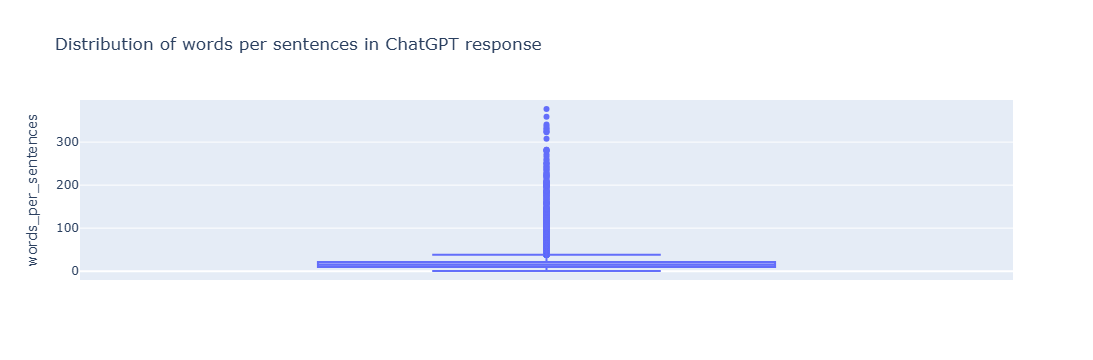

In [130]:
px.box(sf, y = "words_per_sentences", title = "Distribution of words per sentences in ChatGPT response" )

## 7. Does Additional Context Improve ChatGPT responses?

In [131]:
sf.head(1)

,instruction,input,output,text,prompt_type,flesch_score,readibility_level,instruction_word_count,sentence_count,output_word_count,words_per_sentences
0,Give three tips for staying healthy.,,1. Eat a balanced and nutritious diet: Make su...,Below is an instruction that describes a task....,Listing Task,50.853636,Medium,6,10,121,12.1


In [135]:
sf["input"] = sf["input"].replace("", "None")

In [136]:
sf["input"]

0                                                     none
1                                                     none
2                                                     none
3                                                     none
4                                                     none
                               ...                        
51997                                                 none
51998                                     cake, me, eating
51999                                       Michelle Obama
52000                                                 none
52001    The following is an excerpt from a contract be...
Name: input, Length: 52002, dtype: object

In [158]:
sf["input"] = sf["input"].apply(
    lambda x: None if str(x).strip().lower() in ["", "none", "nan", "null"] else x
)

sf["has_input"] = sf["input"].apply(lambda x: 0 if pd.isna(x) else 1)

In [159]:
sf["has_input"].value_counts()

has_input
0    31335
1    20667
Name: count, dtype: int64

In [172]:
comparison = sf.groupby(['has_input'])[["output_word_count", "flesch_score"]].mean().reset_index()
comparison

,has_input,output_word_count,flesch_score
0,0,138.469060,46.353716
1,1,66.043548,53.218378


In [161]:
sf.columns

Index(['instruction', 'input', 'output', 'text', 'prompt_type', 'flesch_score',
       'readibility_level', 'instruction_word_count', 'sentence_count',
       'output_word_count', 'words_per_sentences', 'input_flag', 'has_input'],
      dtype='object')

In [168]:
print("has_input" in comparison.columns)
print(comparison.head(2))

False
           output_word_count  flesch_score
has_input                                 
0                 138.469060     46.353716
1                  66.043548     53.218378


In [173]:
comparison["Context"] = comparison["has_input"].map({0:"No extra context", 1:"Extra context"})

In [174]:
comparison

,has_input,output_word_count,flesch_score,Context
0,0,138.469060,46.353716,No extra context
1,1,66.043548,53.218378,Extra context


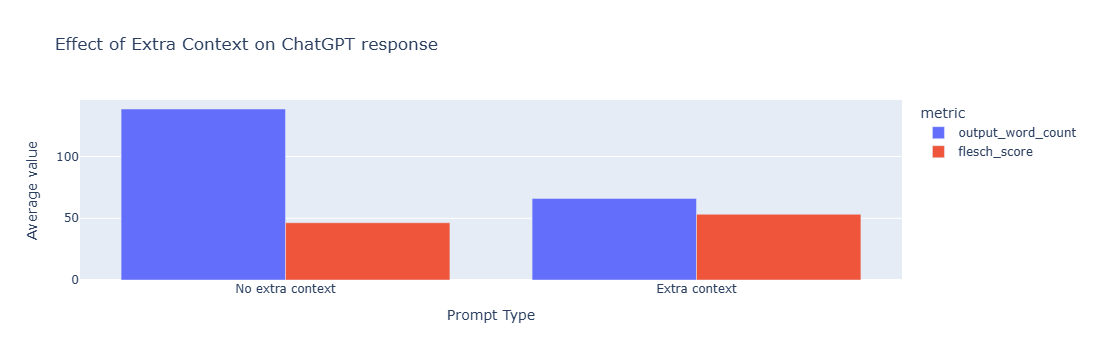

In [178]:
px.bar(comparison, x = "Context", y = ["output_word_count", "flesch_score"], barmode= "group", title = "Effect of Extra Context on ChatGPT response",
      labels={
          'value':"Average value",
          "variable":"metric",
          "Context":"Prompt Type"
      })